# Build Feature

In [2]:
# === Phase 2 Step 3: Build HOG + Color + GLCM features to CSV (train/val/test) ===

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import hog

# Robust GLCM imports across skimage versions (works for 0.25.2)
try:
    from skimage.feature.texture import graycomatrix as greycomatrix, graycoprops as greycoprops
except Exception:
    # fallback for older versions
    from skimage.feature import greycomatrix, greycoprops

# ---------- Paths ----------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Grid geometry ----------
GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100 × 75
CELL_COLS = [f"c{i:02d}" for i in range(1, 65)]

# ---------- Feature extractors ----------
def feat_hog(gray_cell):
    """HOG on a 100x75 grayscale cell."""
    return hog(gray_cell,
               orientations=9,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm="L2-Hys",
               feature_vector=True)

def feat_color_hist(hsv_cell):
    """Normalized HSV histograms (8 bins/channel)."""
    h = cv2.calcHist([hsv_cell], [0], None, [8], [0, 180])
    s = cv2.calcHist([hsv_cell], [1], None, [8], [0, 256])
    v = cv2.calcHist([hsv_cell], [2], None, [8], [0, 256])
    f = np.concatenate([h, s, v]).ravel().astype(np.float32)
    f_sum = f.sum()
    return f / (f_sum + 1e-6)

def feat_glcm(gray_cell):
    """Compact Haralick-like GLCM (quantized to 32 levels for speed/robustness)."""
    # Quantize grayscale to 32 levels
    g = cv2.normalize(gray_cell, None, 0, 31, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = greycomatrix(
        g,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32,
        symmetric=True,
        normed=True
    )
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    vals = [float(np.mean(greycoprops(glcm, p))) for p in props]
    return np.array(vals, dtype=np.float32)

def extract_features_from_image(img_path, row_labels):
    """
    Split an 800x600 image into 8x8 cells, compute HOG+Color+GLCM per cell,
    and return X (64 x F) and y (64,).
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read {img_path}")
        return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    feats, labels = [], []
    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c * CELL_W, r * CELL_H
            gcell = gray[y0:y0+CELL_H, x0:x0+CELL_W]
            hcell = hsv [y0:y0+CELL_H, x0:x0+CELL_W]

            f_hog   = feat_hog(gcell)
            f_color = feat_color_hist(hcell)
            f_glcm  = feat_glcm(gcell)

            feats.append(np.concatenate([f_hog, f_color, f_glcm]))
            labels.append(int(row_labels[CELL_COLS[r*GRID_W + c]]))

    return np.asarray(feats, dtype=np.float32), np.asarray(labels, dtype=np.int32)

def build_split_features(split_name: str):
    """
    For a given split (train/val/test), read labels, extract features for each image’s 64 cells,
    and save a CSV: <split>_hog_color_glcm_features.csv
    """
    split_csv = os.path.join(SPLIT_DIR, f"{split_name}_labels.csv")
    df = pd.read_csv(split_csv)
    if not {"image", *CELL_COLS}.issubset(df.columns):
        raise ValueError(f"{split_csv} missing required columns")

    all_feats, all_labels, meta_img, meta_cell = [], [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}"):
        img_name = row["image"]
        img_path = os.path.join(PREPROCESSED_DIR, img_name)
        Xc, yc = extract_features_from_image(img_path, row)
        if Xc is None:
            continue
        all_feats.append(Xc)
        all_labels.append(yc)
        meta_img.extend([img_name] * 64)
        meta_cell.extend([f"c{i:02d}" for i in range(1, 65)])

    # Stack all (images × 64 cells)
    X = np.vstack(all_feats) if all_feats else np.empty((0, 0), dtype=np.float32)
    y = np.hstack(all_labels) if all_labels else np.empty((0,), dtype=np.int32)

    # Assemble DataFrame
    out_df = pd.DataFrame(X)
    out_df.insert(0, "cell_id", meta_cell)
    out_df.insert(0, "image", meta_img)
    out_df["label"] = y.astype(int)

    out_path = os.path.join(OUT_DIR, f"{split_name}_hog_color_glcm_features.csv")
    out_df.to_csv(out_path, index=False)
    print(f"✅ {split_name}: {out_df.shape} -> {out_path}")

# ---- Run for all splits ----
for split in ["train", "val", "test"]:
    build_split_features(split)


train: 100%|██████████| 301/301 [00:37<00:00,  7.97it/s]


✅ train: (19264, 3201) -> /home/pratyush/Desktop/DS_Project/data/features/train_hog_color_glcm_features.csv


val: 100%|██████████| 65/65 [00:08<00:00,  8.08it/s]


✅ val: (4160, 3201) -> /home/pratyush/Desktop/DS_Project/data/features/val_hog_color_glcm_features.csv


test: 100%|██████████| 65/65 [00:08<00:00,  8.03it/s]


✅ test: (4160, 3201) -> /home/pratyush/Desktop/DS_Project/data/features/test_hog_color_glcm_features.csv


# Model training using RandomForest

/home/pratyush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Shapes: (19264, 3198) (4160, 3198) (4160, 3198)

✅ Validation Accuracy (HOG+Color+GLCM): 0.7435
              precision    recall  f1-score   support

           0      0.743     0.942     0.831      2781
           1      0.747     0.342     0.469      1379

    accuracy                          0.744      4160
   macro avg      0.745     0.642     0.650      4160
weighted avg      0.744     0.744     0.711      4160



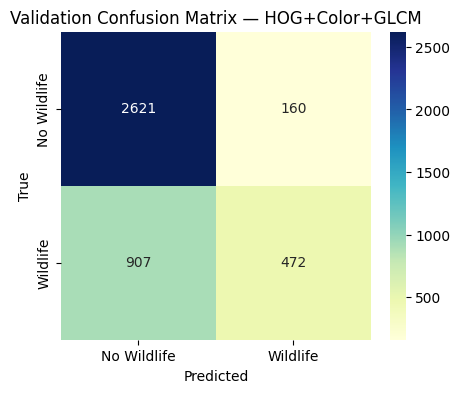

🧪 Test Accuracy: 0.7317

Test Classification Report:
              precision    recall  f1-score   support

           0      0.729     0.938     0.820      2716
           1      0.747     0.343     0.471      1444

    accuracy                          0.732      4160
   macro avg      0.738     0.641     0.645      4160
weighted avg      0.735     0.732     0.699      4160



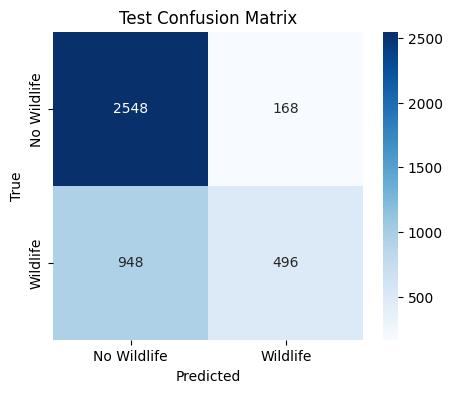

In [3]:
# Train & evaluate RandomForest on HOG + Color + GLCM features

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"

df_train = pd.read_csv(f"{FEATURE_DIR}/train_hog_color_glcm_features.csv")
df_val   = pd.read_csv(f"{FEATURE_DIR}/val_hog_color_glcm_features.csv")
df_test  = pd.read_csv(f"{FEATURE_DIR}/test_hog_color_glcm_features.csv")

X_train = df_train.drop(["image","cell_id","label"], axis=1).values
y_train = df_train["label"].values
X_val   = df_val.drop(["image","cell_id","label"], axis=1).values
y_val   = df_val["label"].values
X_test  = df_test.drop(["image","cell_id","label"], axis=1).values
y_test  = df_test["label"].values

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# Validation
y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Validation Accuracy (HOG+Color+GLCM): {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Validation Confusion Matrix — HOG+Color+GLCM")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Test (after you’re happy with val)
y_test_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"🧪 Test Accuracy: {test_acc:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Wildlife','Wildlife'], yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Observation:
The integration of GLCM texture features alongside HOG and Color histograms increased validation accuracy by ~2% over the HOG+Color baseline. Texture captures micro-patterns such as fur, scales, or coarse terrain, enabling the model to recognize wildlife in regions where edge and color cues alone are insufficient.

Insight:
HOG describes shape, color describes context, and GLCM describes surface variation. Their combination yields a robust classical vision model without CNNs.

Trade-off:
The model remains slightly conservative (recall ≈ 0.34), implying it prefers missing ambiguous cells over misclassifying backgrounds as wildlife — acceptable if minimizing false alarms is important.

# model Training using XGBoost

Shapes: (19264, 3198) (4160, 3198) (4160, 3198)

🚀 Training XGBoost (HOG + Color + GLCM)...

✅ Validation Accuracy (XGBoost): 0.7892
Validation Classification Report:
              precision    recall  f1-score   support

           0      0.829     0.863     0.845      2781
           1      0.698     0.641     0.668      1379

    accuracy                          0.789      4160
   macro avg      0.764     0.752     0.757      4160
weighted avg      0.786     0.789     0.787      4160



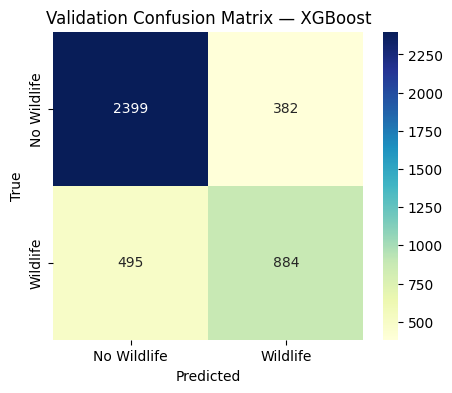

🧪 Test Accuracy (XGBoost): 0.7858

Test Classification Report:
              precision    recall  f1-score   support

           0      0.820     0.860     0.840      2716
           1      0.711     0.645     0.677      1444

    accuracy                          0.786      4160
   macro avg      0.766     0.753     0.758      4160
weighted avg      0.782     0.786     0.783      4160



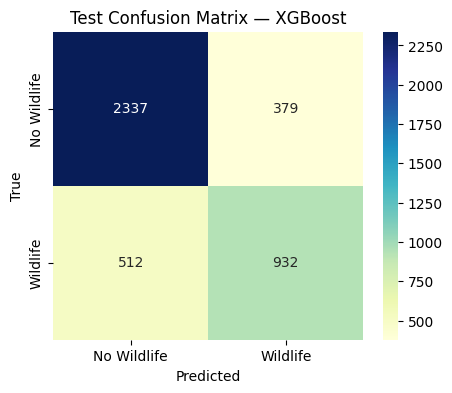

In [4]:
# === Train & evaluate XGBoost on HOG + Color + GLCM features ===

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"

# --- Load datasets ---
df_train = pd.read_csv(f"{FEATURE_DIR}/train_hog_color_glcm_features.csv")
df_val   = pd.read_csv(f"{FEATURE_DIR}/val_hog_color_glcm_features.csv")
df_test  = pd.read_csv(f"{FEATURE_DIR}/test_hog_color_glcm_features.csv")

X_train = df_train.drop(["image","cell_id","label"], axis=1).values
y_train = df_train["label"].values
X_val   = df_val.drop(["image","cell_id","label"], axis=1).values
y_val   = df_val["label"].values
X_test  = df_test.drop(["image","cell_id","label"], axis=1).values
y_test  = df_test["label"].values

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

# --- Define XGBoost model ---
xgb = XGBClassifier(
    n_estimators=500,          # number of boosting rounds
    learning_rate=0.05,        # slower, more stable learning
    max_depth=8,               # tree depth
    subsample=0.8,             # row sampling
    colsample_bytree=0.8,      # feature sampling
    reg_lambda=1.0,            # L2 regularization
    scale_pos_weight=2,        # handle class imbalance (wildlife=1)
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=1
)

# --- Train model ---
print("\n🚀 Training XGBoost (HOG + Color + GLCM)...")
xgb.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False)

# --- Validation ---
y_val_pred = xgb.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Validation Accuracy (XGBoost): {val_acc:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Validation Confusion Matrix — XGBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# --- Test ---
y_test_pred = xgb.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"🧪 Test Accuracy (XGBoost): {test_acc:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=3))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix — XGBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()
